In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:

import os

os.listdir()

['.config',
 'Online Retail Data Set.csv',
 'Online Retail Data Set.xlsx',
 'sample_data']

In [4]:
df = pd.read_csv("Online Retail Data Set.csv", encoding="latin1")

In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [6]:
df.shape

(541909, 8)

In [7]:
encoding="latin1"

In [8]:
# Check the number of rows and columns
print("Dataset Shape:", df.shape)

# Check column names, data types, and missing values
df.info()

Dataset Shape: (541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [9]:
# Check missing values in each column
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [10]:
# Display basic statistics
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [11]:
# Check missing Customer IDs
print("Missing Customer IDs:", df["CustomerID"].isnull().sum())

Missing Customer IDs: 135080


In [12]:
# Remove rows without CustomerID
df = df.dropna(subset=["CustomerID"])

print("Dataset shape after removing missing Customer IDs:", df.shape)

Dataset shape after removing missing Customer IDs: (406829, 8)


In [13]:
# Check cancelled transactions
cancelled = df["InvoiceNo"].astype(str).str.startswith("C")

print("Cancelled Transactions:", cancelled.sum())

Cancelled Transactions: 8905


In [14]:
# Keep only completed transactions
df = df[~cancelled]

print("Dataset shape after removing cancelled transactions:", df.shape)

Dataset shape after removing cancelled transactions: (397924, 8)


In [15]:
# Calculate total amount for each transaction
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

# Check the result
df[["Quantity", "UnitPrice", "TotalAmount"]].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [16]:
# Check for negative quantities or amounts
print("Negative Quantity:", (df["Quantity"] < 0).sum())
print("Negative Total Amount:", (df["TotalAmount"] < 0).sum())

Negative Quantity: 0
Negative Total Amount: 0


In [18]:
# Convert InvoiceDate to datetime format
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    dayfirst=True
)

# Set a reference date after the last transaction
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2011-12-10 12:50:00


In [19]:
# Create RFM analysis

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

# Rename the columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

# Display the RFM table
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [20]:
print("Number of customers:", rfm.shape[0])
print(rfm.describe())

Number of customers: 4339
           Recency    Frequency       Monetary
count  4339.000000  4339.000000    4339.000000
mean     92.518322     4.271952    2053.793018
std     100.009747     7.705493    8988.248381
min       1.000000     1.000000       0.000000
25%      18.000000     1.000000     307.245000
50%      51.000000     2.000000     674.450000
75%     142.000000     5.000000    1661.640000
max     374.000000   210.000000  280206.020000


In [21]:
# Descriptive statistics for RFM features

print("Average Recency:", rfm["Recency"].mean())
print("Average Purchase Frequency:", rfm["Frequency"].mean())
print("Average Customer Lifetime Value:", rfm["Monetary"].mean())

print("\nRFM Summary Statistics:")
print(rfm.describe())

Average Recency: 92.51832219405392
Average Purchase Frequency: 4.271952062687255
Average Customer Lifetime Value: 2053.793017746025

RFM Summary Statistics:
           Recency    Frequency       Monetary
count  4339.000000  4339.000000    4339.000000
mean     92.518322     4.271952    2053.793018
std     100.009747     7.705493    8988.248381
min       1.000000     1.000000       0.000000
25%      18.000000     1.000000     307.245000
50%      51.000000     2.000000     674.450000
75%     142.000000     5.000000    1661.640000
max     374.000000   210.000000  280206.020000


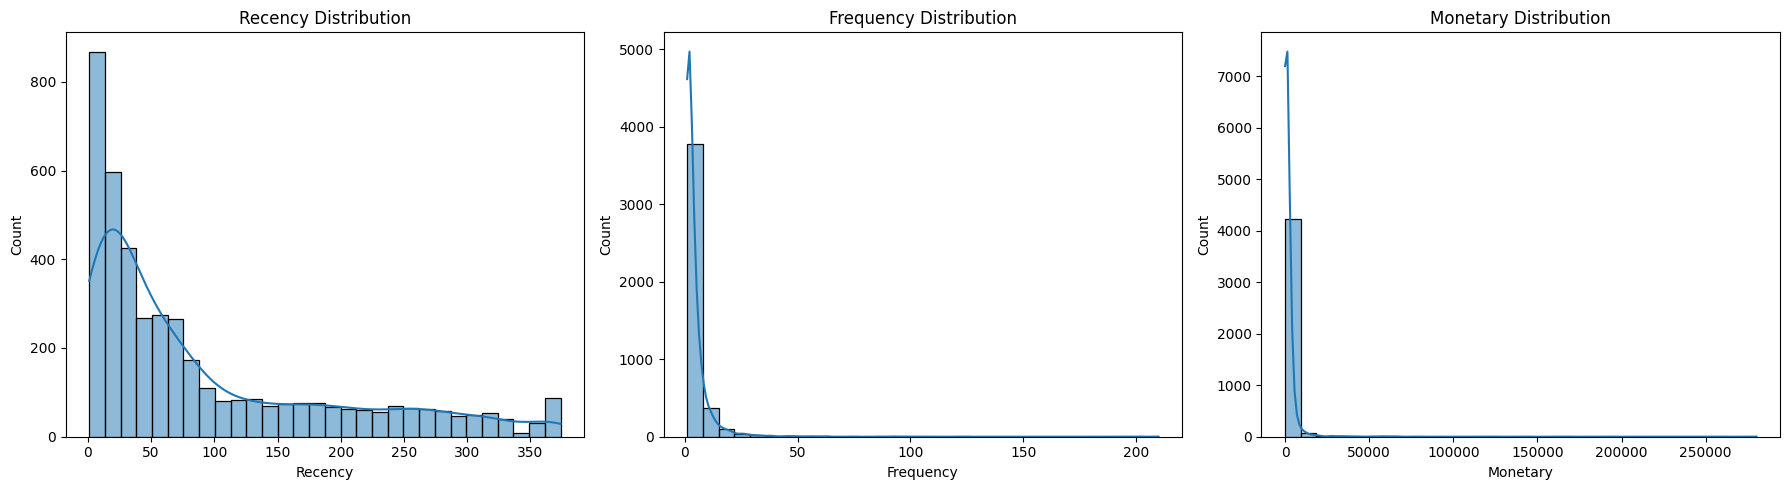

In [22]:
# Distribution of RFM features

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

In [23]:
# Select the features for clustering
rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

# Standardise the features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert back to a DataFrame
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm.index
)

# Display the standardised data
rfm_scaled_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334858,-0.424675,8.359634
12347.0,-0.905199,0.354080,0.251046
12348.0,-0.175186,-0.035297,-0.028546
12349.0,-0.735196,-0.424675,-0.032963
12350.0,2.174855,-0.424675,-0.191315


In [24]:
print(rfm_scaled_df.describe())

            Recency     Frequency      Monetary
count  4.339000e+03  4.339000e+03  4.339000e+03
mean   7.532834e-17  1.965087e-17 -4.093931e-17
std    1.000115e+00  1.000115e+00  1.000115e+00
min   -9.151995e-01 -4.246749e-01 -2.285239e-01
25%   -7.451965e-01 -4.246749e-01 -1.943370e-01
50%   -4.151906e-01 -2.948824e-01 -1.534784e-01
75%    4.948256e-01  9.449517e-02 -4.363455e-02
max    2.814867e+00  2.670196e+01  3.094978e+01


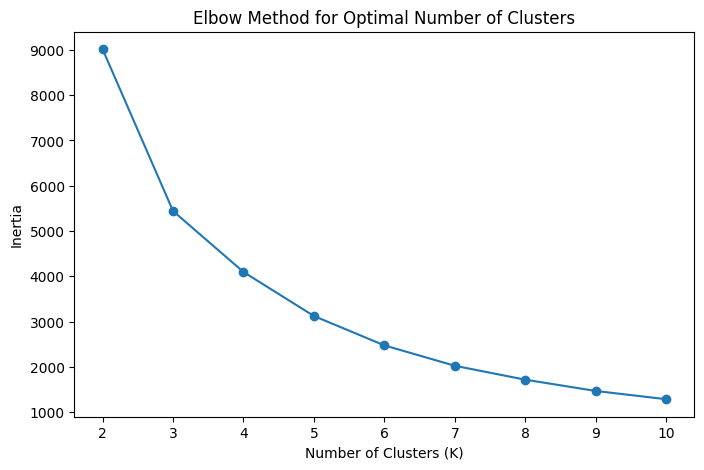

In [25]:
# Calculate inertia for different numbers of clusters

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled_df)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method

plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.show()

In [26]:
for k, value in zip(range(2, 11), inertia):
    print(f"K = {k}: Inertia = {value:.2f}")

K = 2: Inertia = 9014.23
K = 3: Inertia = 5440.36
K = 4: Inertia = 4093.50
K = 5: Inertia = 3120.87
K = 6: Inertia = 2472.39
K = 7: Inertia = 2022.11
K = 8: Inertia = 1714.86
K = 9: Inertia = 1465.71
K = 10: Inertia = 1283.38


In [27]:
# Apply K-Means clustering with 3 clusters

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled_df)

# Display the first rows
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,1
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [28]:
# Count customers in each cluster

cluster_counts = rfm["Cluster"].value_counts().sort_index()

print(cluster_counts)

Cluster
0    3231
1    1082
2      26
Name: count, dtype: int64


In [29]:
# Calculate average RFM values for each cluster

cluster_profile = rfm.groupby("Cluster")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean().round(2)

print(cluster_profile)

         Recency  Frequency  Monetary
Cluster                              
0          41.45       4.67   1855.37
1         247.11       1.58    631.42
2           6.04      66.50  85904.35


In [30]:
# Number of customers in each cluster

cluster_profile["Customer_Count"] = rfm.groupby("Cluster").size()

print(cluster_profile)

         Recency  Frequency  Monetary  Customer_Count
Cluster                                              
0          41.45       4.67   1855.37            3231
1         247.11       1.58    631.42            1082
2           6.04      66.50  85904.35              26


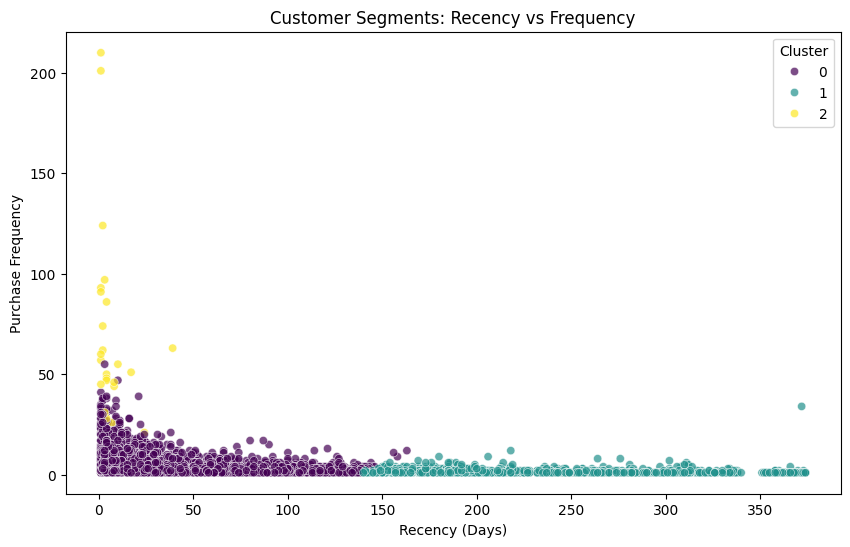

In [31]:
# Recency vs Frequency

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="viridis",
    alpha=0.7
)

plt.title("Customer Segments: Recency vs Frequency")
plt.xlabel("Recency (Days)")
plt.ylabel("Purchase Frequency")
plt.legend(title="Cluster")
plt.show()

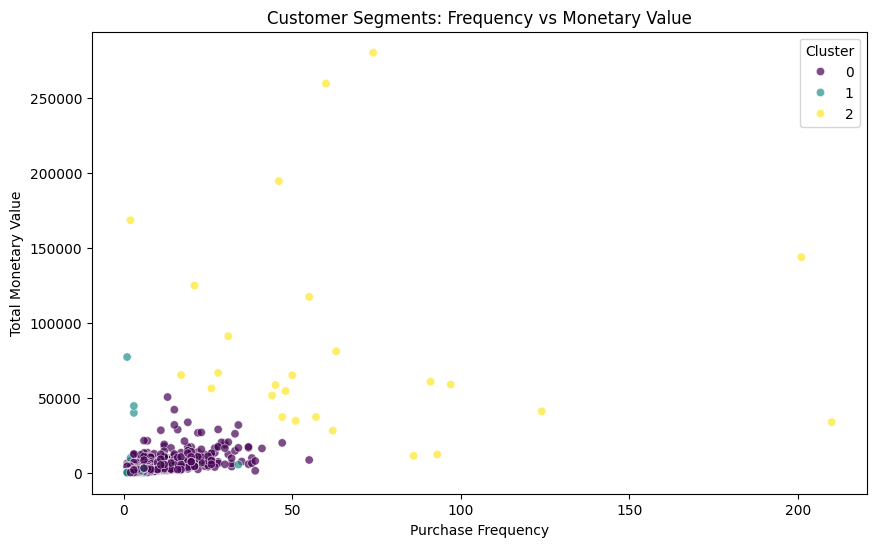

In [32]:
# Frequency vs Monetary Value

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="viridis",
    alpha=0.7
)

plt.title("Customer Segments: Frequency vs Monetary Value")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Monetary Value")
plt.legend(title="Cluster")
plt.show()

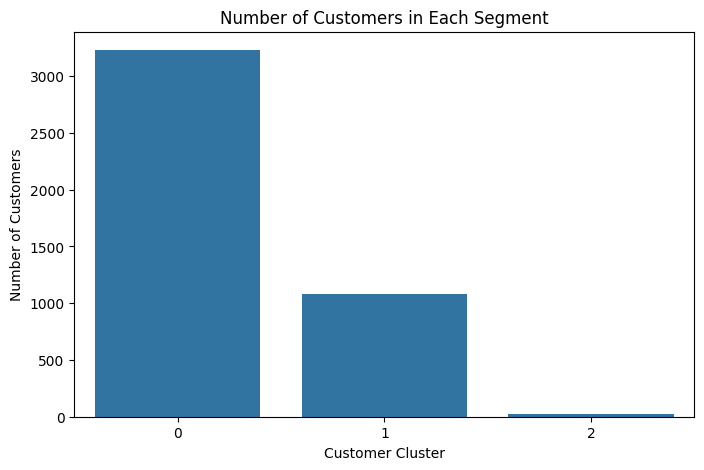

In [33]:
# Count customers in each cluster

cluster_counts = rfm["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Customers in Each Segment")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [34]:
# Assign meaningful names to the customer clusters

cluster_names = {
    0: "Regular Customers",
    1: "At-Risk Customers",
    2: "High-Value Loyal Customers"
}

rfm["Customer_Segment"] = rfm["Cluster"].map(cluster_names)

# Display the final customer segmentation
rfm.head()

,Recency,Frequency,Monetary,Cluster,Customer_Segment
CustomerID,,,,,
12346.0,326,1,77183.60,1,At-Risk Customers
12347.0,2,7,4310.00,0,Regular Customers
12348.0,75,4,1797.24,0,Regular Customers
12349.0,19,1,1757.55,0,Regular Customers
12350.0,310,1,334.40,1,At-Risk Customers


In [35]:
# Customer segment distribution

print(rfm["Customer_Segment"].value_counts())

Customer_Segment
Regular Customers             3231
At-Risk Customers             1082
High-Value Loyal Customers      26
Name: count, dtype: int64


## Customer Segment Profiles and Marketing Recommendations

### 1. Regular Customers
- Customers: 3,231
- Average Recency: 41.45 days
- Average Frequency: 4.67 purchases
- Average Monetary Value: £1,855.37

These customers purchase relatively recently and show moderate purchase frequency and spending.

**Marketing Recommendation:**
Use personalised product recommendations, loyalty rewards, and targeted promotions to encourage these customers to increase their purchase frequency and become high-value loyal customers.

### 2. At-Risk Customers
- Customers: 1,082
- Average Recency: 247.11 days
- Average Frequency: 1.58 purchases
- Average Monetary Value: £631.42

These customers have not purchased recently and have the lowest purchase frequency and spending.

**Marketing Recommendation:**
Use re-engagement campaigns, personalised discounts, reminder emails, and special offers to encourage them to return.

### 3. High-Value Loyal Customers
- Customers: 26
- Average Recency: 6.04 days
- Average Frequency: 66.50 purchases
- Average Monetary Value: £85,904.35

These customers purchase very frequently, purchased very recently, and have extremely high total spending.

**Marketing Recommendation:**
Reward these customers with VIP loyalty programmes, exclusive offers, early access to new products, and personalised premium services.

## Key Insights

- The customer base was segmented into three distinct groups using RFM analysis and K-Means clustering.
- Regular Customers formed the largest segment, with 3,231 customers.
- At-Risk Customers represented 1,082 customers and showed the highest average recency of 247.11 days, indicating a need for re-engagement campaigns.
- High-Value Loyal Customers were the smallest segment, with only 26 customers, but had extremely high purchase frequency and monetary value.
- The High-Value Loyal Customer segment had an average frequency of 66.50 purchases and an average monetary value of £85,904.35.
- RFM-based customer segmentation can help businesses create targeted marketing strategies for different customer groups.